# Project 2: What Discounting Does to Profit in Retail Orders

A regression project for DTSC 2301.

This notebook is my second portfolio project. I'm predicting `Profit` on a retail order using a regression model, focused on how discounting and product category relate to whether an order actually makes money.

## 1. Problem Definition

This is a regression problem. My target variable is `Profit`, a continuous dollar amount that can be positive (the order made money) or negative (the order lost money). I'm not sorting orders into buckets like "profitable" or "not profitable," which would be classification; I'm predicting the actual dollar value.

The person who benefits from this is a pricing or merchandising analyst at a retailer who wants to understand how discount levels and product category affect the bottom line, not just the top line (sales revenue).

Retailers use discounts constantly to drive volume, but a discount that's too deep can turn a sale into a net loss. If a company can't see where that tipping point is, it ends up subsidizing sales it thinks are helping the business. My question going in: how much do discount percentage and product category actually explain about whether an order makes or loses money, and where's the breaking point?

## 2. Background and Context

Retailers have used discounting as a promotional tool for decades, but the relationship between discount depth and profitability isn't linear. A small discount might cost almost nothing in margin while still driving extra volume, but past a certain point the discount costs more than the extra volume brings in. Blattberg and Neslin (1990) describe this trade-off in their foundational work on sales promotions: discounts shift when and how much customers buy, but each promotion type carries its own margin cost that has to be weighed against the volume it generates.

On the modeling side, I compared a simple, interpretable model against a more flexible one. Breiman (2001), who introduced the random forest algorithm I used here, points out that ensembles of decision trees can capture non-linear relationships and interactions between variables that a straight-line model can't. That matters here because I'd expect the cost of a discount to depend on which product category it's applied to, not just the discount percentage alone.

This project also involves picking which columns to feed into a model, so I wanted to be upfront about a modeling pitfall called data leakage: using information that wouldn't actually be available, or that's circularly related to the target, at prediction time. Kaufman, Rosset, Perlich, and Stitelman (2012) give a detailed breakdown of how leakage sneaks into real analytics projects, and it shaped how I handled the Sales column later in this notebook (Section 5).

Once a model like this works, the next question is what to do with it. Bertsimas and Kallus (2020) argue that predictive models are only half the work; the real value comes from turning a prediction into a decision, such as a discount cap on a specific category. I come back to this in the Limitations and Reflection section, because a model that predicts profit isn't the same thing as a model that tells you the right discount policy.

## 3. Data Description

This is the "Sample Superstore" dataset, a widely used public training dataset originally distributed by Tableau Software for teaching data analysis. I pulled a CSV mirror of it from GitHub at `https://raw.githubusercontent.com/leonism/sample-superstore/master/data/superstore.csv` and saved it locally in this repo at `data/superstore.csv`, so the notebook doesn't depend on that link staying live.

I'm using this public sample dataset instead of real data from my own retail job on purpose. I have hands-on access to real retail systems through work, but that data isn't mine to publish on a public class portfolio, so I picked a dataset built for this kind of practice instead.

Each row is one line item on a customer order: an order with two different products is two rows, not one. The target variable is `Profit`, in dollars. The candidate features are `Sales` (dollar amount of the line item), `Quantity`, `Discount` (0 to 0.8, as a decimal percentage), `Category` and `Sub-Category` (what kind of product), `Region`, `Segment` (Consumer, Corporate, or Home Office), and `Ship Mode`.

The raw file actually contains three different tables stuffed into one CSV, which I get into below, but the real order-level dataset is 9,994 rows and 21 columns once isolated.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

raw = pd.read_csv("data/superstore.csv", encoding="latin1")
print("Raw file shape:", raw.shape)
raw.head(3)

Raw file shape: (10800, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.0,0.0,41.9136
1,2,CA-2017-152156,11/8/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,0.0,219.5820
2,3,CA-2017-138688,6/12/2017,6/16/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,0.0,6.8714


Loading the file turned up something the dataset description didn't mention: the CSV mirror has 10,800 rows, not 9,994. The extra rows aren't orders. The original Tableau workbook has three separate sheets (Orders, Returns, and a People/Region-manager list), and whoever converted it to a single CSV stacked all three sheets on top of each other with no separator. The "extra" rows have a return record or a manager's name sitting in the same columns as real order data, which is why `Sales` and `Profit` are blank for those rows.

I'm only using the Orders portion for this project. The Returns and People sheets are a different unit of analysis entirely (an order ID that was returned, and a person's name and region), and mixing them in would mean comparing unrelated things. I filtered down to real order rows by keeping only rows where `Sales` and `Profit` are both present.

In [2]:
orders = raw[raw["Sales"].notna() & raw["Profit"].notna()].copy()
print("Orders-only shape:", orders.shape)
print("Fully duplicated rows:", orders.duplicated().sum())
print("Duplicate Row IDs:", orders["Row ID"].duplicated().sum())
orders.isna().sum()[orders.isna().sum() > 0]

Orders-only shape: (9994, 21)
Fully duplicated rows: 0
Duplicate Row IDs: 0


Postal Code    11
dtype: int64

That cleanup gets me to exactly 9,994 rows, with no duplicate rows and no duplicate Row IDs. That matches the dataset's well-documented canonical size, which tells me I isolated the right table. The only missing values left are 11 blank `Postal Code` entries, and I'm not using that column as a feature, so it doesn't affect anything downstream.

## 4. Data Understanding and Exploration

Before any modeling, I looked at what's actually going on with Profit.

In [3]:
orders[["Sales", "Quantity", "Discount", "Profit"]].describe()

,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,3.789574,0.156203,28.656896
std,623.245101,2.225110,0.206452,234.260108
min,0.444000,1.000000,0.000000,-6599.978000
25%,17.280000,2.000000,0.000000,1.728750
50%,54.490000,3.000000,0.200000,8.666500
75%,209.940000,5.000000,0.200000,29.364000
max,22638.480000,14.000000,0.800000,8399.976000


A few things stand out in those summary statistics. `Profit` ranges from a loss of about -$6,600 to a gain of about $8,400 on a single line item, and the standard deviation ($234) is much bigger than the mean ($28.66): profit swings widely rather than clustering around a typical value. That's a strong hint that a few variables are doing a lot of the explanatory work.

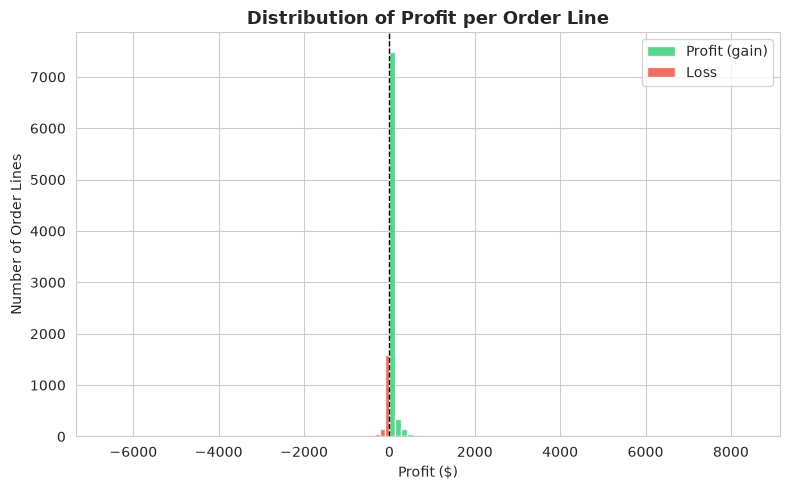

Share of order lines that lost money: 18.7%


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(orders.loc[orders["Profit"] >= 0, "Profit"], bins=60, color="#2ecc71", alpha=0.8, label="Profit (gain)")
ax.hist(orders.loc[orders["Profit"] < 0, "Profit"], bins=60, color="#e74c3c", alpha=0.8, label="Loss")
ax.set_title("Distribution of Profit per Order Line", fontsize=13, fontweight="bold")
ax.set_xlabel("Profit ($)")
ax.set_ylabel("Number of Order Lines")
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.legend()
plt.tight_layout()
plt.savefig("assets/img/project2/profit_distribution.png", dpi=150)
plt.show()

loss_rate = (orders["Profit"] < 0).mean()
print(f"Share of order lines that lost money: {loss_rate:.1%}")

About 18.7% of all order lines lose money: nearly one in five orders is a net loss on paper. That's common enough to justify building a model around it, since the simple assumption that "most orders are profitable" doesn't capture what's actually happening.

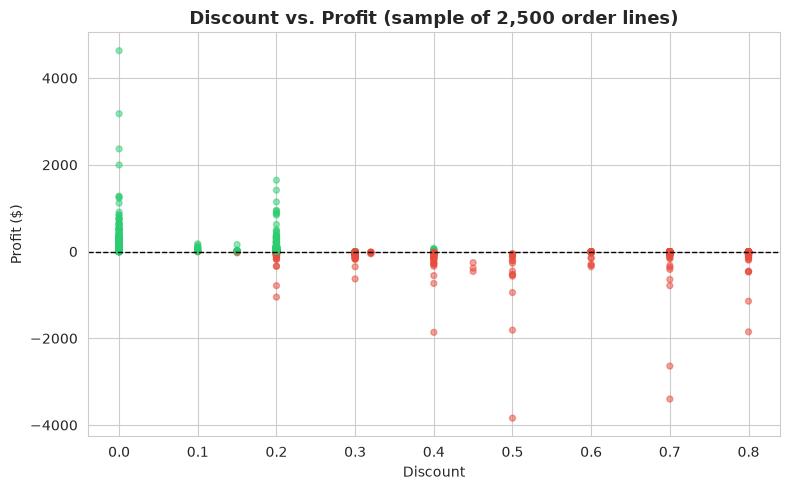

,mean,count
discount_bucket,,
"(-0.01, 0.0]",66.900292,4798
"(0.0, 0.2]",26.501571,3803
"(0.2, 0.4]",-77.864055,460
"(0.4, 0.6]",-134.624160,215
"(0.6, 1.0]",-98.348741,718


In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sample = orders.sample(2500, random_state=42)
colors = sample["Profit"].apply(lambda p: "#e74c3c" if p < 0 else "#2ecc71")
ax.scatter(sample["Discount"], sample["Profit"], c=colors, alpha=0.5, s=18)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Discount vs. Profit (sample of 2,500 order lines)", fontsize=13, fontweight="bold")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit ($)")
plt.tight_layout()
plt.savefig("assets/img/project2/discount_vs_profit.png", dpi=150)
plt.show()

bins = [-0.01, 0, 0.2, 0.4, 0.6, 1.0]
orders["discount_bucket"] = pd.cut(orders["Discount"], bins=bins)
orders.groupby("discount_bucket")["Profit"].agg(["mean", "count"])

Average profit is positive at 0 to 20% discount, flips negative once discount passes about 20%, and keeps getting worse through the 40 to 60% discount range. There's a real breaking point here, not a gradual cost, and it lands earlier than I expected.

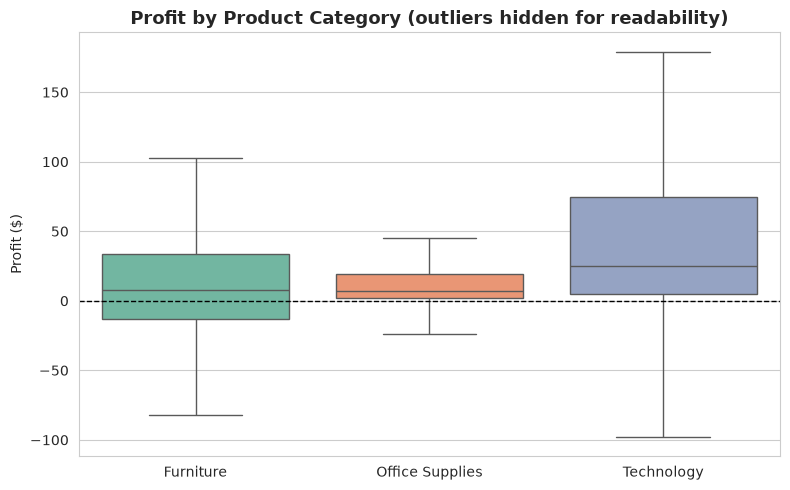

Category
Technology         78.752002
Office Supplies    20.327050
Furniture           8.699327
Name: Profit, dtype: float64

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
order_cats = orders.groupby("Category")["Profit"].mean().sort_values().index
sns.boxplot(data=orders, x="Category", y="Profit", order=order_cats, hue="Category", legend=False, ax=ax, showfliers=False, palette="Set2")
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Profit by Product Category (outliers hidden for readability)", fontsize=13, fontweight="bold")
ax.set_ylabel("Profit ($)")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig("assets/img/project2/profit_by_category.png", dpi=150)
plt.show()

orders.groupby("Category")["Profit"].mean().sort_values(ascending=False)

Category matters too. Technology orders average about $79 profit per line, Office Supplies about $20, and Furniture only about $9, despite Furniture often having higher sales dollar amounts per item. Category is tracking a real difference in how profitable a dollar of sales actually is.

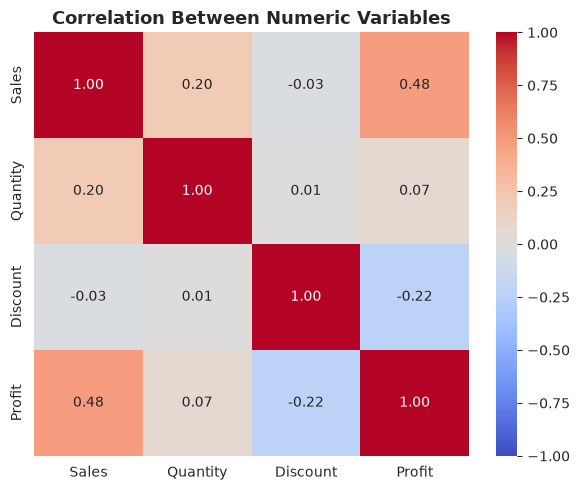

Sales       0.479064
Quantity    0.066253
Discount   -0.219487
Profit      1.000000
Name: Profit, dtype: float64

In [7]:
numeric_cols = ["Sales", "Quantity", "Discount", "Profit"]
corr = orders[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Correlation Between Numeric Variables", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("assets/img/project2/correlation_heatmap.png", dpi=150)
plt.show()

corr["Profit"]

The correlation numbers back up the charts: `Sales` correlates with `Profit` at 0.48, `Discount` at -0.22, and `Quantity` barely at all (0.07). Buying more units doesn't predict profit nearly as much as discount or sale price does.

This exploration points to `Discount`, `Sales`, and `Category` as the features that have to be in the model. `Quantity` is weak on its own, but I kept it anyway since it might interact with other variables in a way a single correlation number can't show, which is part of why I tried a random forest and not only linear regression. I also kept `Region`, `Segment`, and `Ship Mode` as features to see whether the model finds anything there, even though nothing in this exploration pointed to them specifically.

## 5. Data Preparation and Feature Selection

The features I used are `Sales`, `Quantity`, and `Discount` as numeric values, plus `Category`, `Sub-Category`, `Region`, `Segment`, and `Ship Mode` as one-hot encoded categories.

I dropped several columns on purpose: `Row ID`, `Order ID`, `Customer ID`, `Customer Name`, `Product ID`, `Product Name`, `City`, `State`, `Postal Code`, `Country`, `Order Date`, and `Ship Date`. These are identifiers, not predictive signal. A model that "learns" from `Customer Name` is memorizing which specific customers were in the training data, not learning a pattern that generalizes. `Country` is dropped because every row is "United States," so it can't explain any variation.

Models can't read text categories like "Furniture" directly, so I converted each category into its own 0/1 column using `pandas.get_dummies()` (for example, a `Category_Furniture` column that's 1 for furniture rows and 0 otherwise). Doing this before the train/test split is safe specifically because these are small, fixed sets of categories (3 categories, 4 regions, 3 segments, 4 ship modes) guaranteed to appear the same way in both the training and test data. A numeric scaler or an encoding learned from the data's actual values is different, since that does have to be fit on the training set only to avoid leakage.

One feature choice deserves a direct call-out, because it's exactly the kind of trap Kaufman et al. (2012) describe: `Sales` and `Profit` come from the same transaction and are correlated by construction, since profit is roughly sales minus cost. I kept `Sales` in the model anyway, because a retailer knows the sale amount before profit is finalized; it's known at the time of sale, not derived from the Profit column itself. A "was this profitable" flag would be real leakage, since it's just the target in disguise, but `Sales` isn't that. I'm flagging this because it means the model's accuracy is partly inflated by this built-in relationship, which I come back to in the Limitations section.

I split the data 80% train and 20% test using a fixed random seed, so the model is evaluated only on rows it never saw during training. I used a random split rather than a time-based one: unlike a true forecasting problem, I'm not predicting the future from the past, I'm predicting an unknown order's profit from its known characteristics, and a random split fits that better.

In [8]:
model_df = orders[[
    "Sales", "Quantity", "Discount", "Category", "Sub-Category",
    "Region", "Segment", "Ship Mode", "Profit"
]].copy()

model_df = pd.get_dummies(model_df, columns=["Category", "Sub-Category", "Region", "Segment", "Ship Mode"], drop_first=True)

X = model_df.drop(columns=["Profit"])
y = model_df["Profit"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training rows:", X_train.shape[0], " | Test rows:", X_test.shape[0], " | Features:", X_train.shape[1])

Training rows: 7995  | Test rows: 1999  | Features: 29


## 6. Baseline and Model Development

Before trusting any real model, I needed a reference point: a `DummyRegressor` that predicts the average training profit for every order, regardless of its features. If a real model can't beat that, it isn't adding value.

The first model is Linear Regression, which fits a straight-line relationship between each feature and profit. I used it because it's easy to interpret: each feature gets exactly one coefficient, showing its direction and rough size of effect.

The second is a Random Forest Regressor, which builds many decision trees, each a series of yes/no splits like "is Discount greater than 0.3," and averages their predictions. Breiman (2001) notes that this approach is good at picking up non-linear effects and interactions between variables. That matters here, since the exploration above suggested discount's effect on profit isn't a straight line and might depend on category.

These two models sit at opposite ends of a trade-off I'd actually face as an analyst: Linear Regression is easy to explain to a non-technical stakeholder one coefficient at a time, while Random Forest can likely fit the data better but takes more work to interpret. Section 8 deals with that trade-off directly.

Both models trained on the same `X_train`/`y_train` and were evaluated on the same `X_test`/`y_test`, so the comparison in the next section is fair.

In [9]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

linreg = LinearRegression()
linreg.fit(X_train, y_train)

rf = RandomForestRegressor(n_estimators=300, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print("Models trained: baseline, linear regression, random forest.")

Models trained: baseline, linear regression, random forest.


## 7. Model Evaluation and Selection

I used three metrics, each answering a different question:

- MAE (Mean Absolute Error): on average, how many dollars off is a typical prediction? This is the easiest one to explain to a non-technical stakeholder.
- RMSE (Root Mean Squared Error): similar to MAE, but it penalizes large misses more heavily. That matters here, since a model that's usually close but occasionally wildly wrong on a huge order is a bigger business risk than one that's consistently a little off.
- R² (R-squared): what fraction of the variation in profit the model explains, from 0 (no better than the baseline) to 1 (perfect).

All three are computed on the test set only, the 20% of rows none of the models saw during training.

In [10]:
def evaluate(name, model, X_tr, y_tr, X_te, y_te):
    pred_train = model.predict(X_tr)
    pred_test = model.predict(X_te)
    return {
        "Model": name,
        "Train R2": r2_score(y_tr, pred_train),
        "Test MAE": mean_absolute_error(y_te, pred_test),
        "Test RMSE": mean_squared_error(y_te, pred_test) ** 0.5,
        "Test R2": r2_score(y_te, pred_test),
    }

results = pd.DataFrame([
    evaluate("Baseline (mean)", baseline, X_train, y_train, X_test, y_test),
    evaluate("Linear Regression", linreg, X_train, y_train, X_test, y_test),
    evaluate("Random Forest", rf, X_train, y_train, X_test, y_test),
])
results = results.round(2)
results

,Model,Train R2,Test MAE,Test RMSE,Test R2
0,Baseline (mean),0.00,67.55,220.43,-0.00
1,Linear Regression,0.49,67.80,282.42,-0.65
2,Random Forest,0.96,26.65,223.20,-0.03


The baseline's test R² is essentially 0 by definition, since it uses no features at all. I expected both real models to clear that floor on every metric. That's not quite what happened.

MAE is unambiguous: Random Forest's test MAE ($26.65) is far better than both the baseline ($67.55) and Linear Regression ($67.80). On a typical order, Random Forest's prediction is off by about $27, versus about $68 for the other two.

RMSE and R² tell a different story. Random Forest's test R² (-0.03) sits slightly below the baseline's, and Linear Regression's test R² (-0.65) is well below it, meaning Linear Regression does worse than guessing the average profit every time. The reason traces back to the outliers in Section 4: `Profit` ranges down to about -$6,600 and up to about +$8,400 on a single order line. RMSE and R² square every error before averaging, so a handful of giant mistakes on rare, huge-dollar orders can swamp thousands of otherwise-decent predictions. MAE doesn't square anything, so it isn't distorted the same way.

I also compared each model's train R² to its test R²: Random Forest goes from 0.96 to -0.03, and Linear Regression goes from 0.49 to -0.65. Both gaps are large and point to overfitting: each model is partly fitting noise and extreme values specific to the training rows that don't hold up on new data. Random Forest's gap is larger in raw numbers, but it still lands in a far more useful place on MAE, the metric that reflects typical-order accuracy.

I'm picking Random Forest as the final model, with a caveat worth stating plainly: on RMSE and R², it doesn't clearly beat a model that just guesses the average. What it does is cut the typical prediction error by more than half compared to the baseline and Linear Regression. A retail team that cares most about getting a normal, everyday order right should prefer Random Forest. A team specifically worried about rare, catastrophic misses on huge orders shouldn't fully trust any of these three models yet; I come back to this in Section 9. Linear Regression isn't a serious contender here, since it loses to the baseline on every metric, and its usual interpretability advantage isn't worth the accuracy it gives up in this case.

## 8. Model Interpretation and Insights

Random Forest is the chosen model, but it isn't as directly interpretable as Linear Regression, so I looked at both: Random Forest's feature importances (which features it relied on most to make its splits) and Linear Regression's coefficients (the direction and rough size each feature pushes profit), plus where the chosen model is actually getting it wrong.

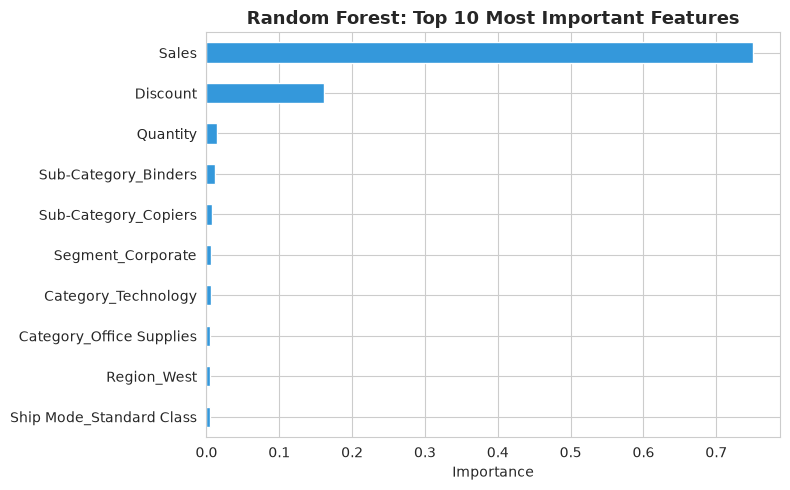

Sales                       0.749952
Discount                    0.160952
Quantity                    0.014853
Sub-Category_Binders        0.011403
Sub-Category_Copiers        0.007847
Segment_Corporate           0.006542
Category_Technology         0.005660
Category_Office Supplies    0.004841
Region_West                 0.004334
Ship Mode_Standard Class    0.004317
dtype: float64

In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 5))
importances.sort_values().plot(kind="barh", ax=ax, color="#3498db")
ax.set_title("Random Forest: Top 10 Most Important Features", fontsize=13, fontweight="bold")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("assets/img/project2/feature_importance.png", dpi=150)
plt.show()

importances

`Sales` and `Discount` dominate the Random Forest's feature importances. `Sales` alone accounts for about 75% of the model's total importance, with `Discount` a distant second at about 16%. A handful of category and sub-category dummy variables show up further down the list, but nothing else comes close to those two. This matches the data-leakage discussion in Section 5: part of why `Sales` dominates so heavily is the built-in sales-profit relationship flagged earlier, not only a newly discovered pattern.

In [12]:
coefs = pd.Series(linreg.coef_, index=X.columns).sort_values()
print("Linear Regression, most negative coefficients (push profit down):")
print(coefs.head(5))
print("\nLinear Regression, most positive coefficients (push profit up):")
print(coefs.tail(5))

Linear Regression, most negative coefficients (push profit down):
Discount                 -237.534624
Sub-Category_Machines    -192.580308
Sub-Category_Tables      -107.703952
Sub-Category_Bookcases    -56.496030
Sub-Category_Supplies     -48.109005
dtype: float64

Linear Regression, most positive coefficients (push profit up):
Category_Office Supplies     52.372694
Category_Technology          57.896844
Sub-Category_Binders         60.804106
Sub-Category_Furnishings     65.271866
Sub-Category_Copiers        271.489062
dtype: float64


Linear Regression's coefficients point the same direction: `Discount` has the single most negative coefficient in the model, meaning that holding everything else constant, a higher discount is associated with lower profit. This agrees with Random Forest's feature importance ranking, even though the two models work completely differently. Two different modeling approaches agreeing on what matters is a stronger signal than either one alone.

In [13]:
rf_pred = rf.predict(X_test)
residuals = y_test - rf_pred
error_df = X_test.copy()
error_df["Actual Profit"] = y_test
error_df["Predicted Profit"] = rf_pred.round(2)
error_df["Error"] = residuals.round(2)

worst = error_df.reindex(error_df["Error"].abs().sort_values(ascending=False).index).head(8)
worst[["Discount", "Sales", "Actual Profit", "Predicted Profit", "Error"]]

,Discount,Sales,Actual Profit,Predicted Profit,Error
2697,0.5,22638.480,-1811.0784,6320.45,-8131.52
683,0.5,7999.980,-3839.9904,-78.87,-3761.12
1803,0.2,4663.736,-1049.3406,1033.61,-2082.95
3151,0.7,1799.994,-2639.9912,-1066.06,-1573.93
9165,0.2,4476.800,503.6400,-824.04,1327.68
5198,0.2,3930.072,-786.0144,517.74,-1303.75
4277,0.0,9099.930,2365.9818,3615.72,-1249.74
9639,0.4,4297.644,-1862.3124,-762.58,-1099.74


The biggest misses are concentrated in orders with unusually large `Sales` amounts. The single worst prediction, an $8,131 miss, happens on the largest `Sales` value in the entire test set: $22,638 on one line item, discounted 50%, actually a $1,811 loss, which the model predicted as a $6,320 gain. This is the kind of order that drags RMSE and R² down in Section 7, even while the model handles thousands of smaller, typical orders well. The model is reliable for everyday order sizes and unreliable for rare, large, one-off ones.

For a store or pricing team, the takeaway is this: discounting past roughly 20% is where margin starts breaking down on average, and that breaking point shows up consistently across a simple average-by-bucket chart, a linear model's coefficients, and a random forest's feature importances. Three different methods landing on the same number is why I trust this finding.

## 9. Limitations, Ethics, and Reflection

This is public sample data, not a real business's books. I chose not to use real data from my own retail job for this project. I have access to real retail systems through work, but that data isn't mine to publish on a public GitHub portfolio, and the confidentiality concerns aren't worth it for a class assignment. Everything here is the "Sample Superstore" training dataset, and none of these numbers describe any real company.

There's no unit cost or cost-of-goods column anywhere in this dataset; `Profit` is given as-is. That means discount and category are strongly associated with profit, which is a meaningful, actionable signal, but I can't fully separate "discount causes lower margin" from "discount happens to correlate with something else in the data," like a product that was already low-margin before any discount was applied. So profit-driver claims here are directional, not provably causal.

A small number of extreme orders also have an outsized effect on how good this model looks. Section 7 covers this, but it belongs here too: whether this model looks like a clear win or basically a tie with the baseline depends on which metric is asked for. That's a real limitation, not a technicality, because my results could look different on a slightly different random train/test split. The test set only has about 2,000 rows, and one or two $20,000 orders landing in that split can swing R² and RMSE substantially. A next step worth trying is log-transforming `Profit` or capping the most extreme values before modeling, which tends to make regression less dominated by a handful of outliers. I didn't do that here because it would make the dollar-amount predictions harder to explain directly, but it's a real trade-off worth revisiting.

The Sales-leakage issue from Section 5 still matters here. Because `Sales` and `Profit` are correlated by construction, some of this model's apparent accuracy comes from that built-in relationship rather than a genuinely new insight. I kept `Sales` in because it's realistically known at the time of sale, but the headline accuracy numbers shouldn't be read as solving profitability prediction; they're inflated somewhat by that relationship.

If a real pricing or store-operations team leaned on a model like this, overreacting to it could cost real sales volume. Bertsimas and Kallus (2020) make this point directly: a prediction isn't automatically a good decision. If a team saw "discounts over 20% lose money" and responded by cutting every deep discount everywhere, it might also kill off sales events that were working for reasons this model can't see, like clearing old inventory or matching a competitor. A false "this discount will lose money" signal costs a missed sale; a false "this discount is fine" signal costs a real loss on that order. Those aren't the same size of mistake, and a team using this would need to know which one it's more worried about.

Before I'd trust this in a real decision, I'd want real cost data, a longer time window (this dataset has no view of discount strategy changing over time), and ideally an actual experiment, such as testing a discount cap on some stores and not others, rather than only looking backward at historical correlations, which can't fully separate the discount's effect from everything else about that order.

## 10. Code and AI Transparency

The full notebook is published at [github.com/yromerog/data-structures-portfolio](https://github.com/yromerog/data-structures-portfolio/blob/main/2nd_project.ipynb), along with the dataset I used (`data/superstore.csv`) and the write-up page on my portfolio site.

Dataset citation: Tableau Software. (n.d.). *Sample – Superstore* [Dataset]. Mirrored from `https://raw.githubusercontent.com/leonism/sample-superstore/master/data/superstore.csv`.

I used Claude Code to help scaffold and debug specific pieces of this notebook: the exact pandas and scikit-learn syntax for one-hot encoding, the train/test split, fitting the three models, and pulling together the comparison table and charts. I also used it to track down and verify the sources cited below. The problem I chose to ask (does discount or category predict profit, and where's the breaking point), which features to include or exclude and why, how to read and interpret the actual results, and the limitations and ethics discussion above are mine. I limited how much I leaned on AI to what I could fully understand, explain, and defend, the same approach I used on my first project.

### References

Bertsimas, D., & Kallus, N. (2020). From predictive to prescriptive analytics. *Management Science, 66*(3), 1025–1044.

Blattberg, R. C., & Neslin, S. A. (1990). *Sales promotion: Concepts, methods, and strategies*. Prentice Hall.

Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32.

Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1–21.